## Filtering, Feature Extraction, Clustering, and Dimensionality Reduction using PCA

In this section, we will perform feature extraction and clustering on our dataset. We will use Principal Component Analysis (PCA) to reduce the dimensionality of the data.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helper.tools import PrincipalComponentAnalysis
from helper.tools import LowPassFilter
from helper.tools import MeanTemporalAbstraction
from sklearn.cluster import KMeans


# plot settings
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams["lines.linewidth"] = 2


In [11]:
# load data
df = pd.read_pickle('../processed_data/dataInterpolated.pkl')
columns = list(df.columns[1:7])
columns_acc = list(df.columns[1:4])
columns_gyro = list(df.columns[4:7])

### **Low Pass Filter**

squat


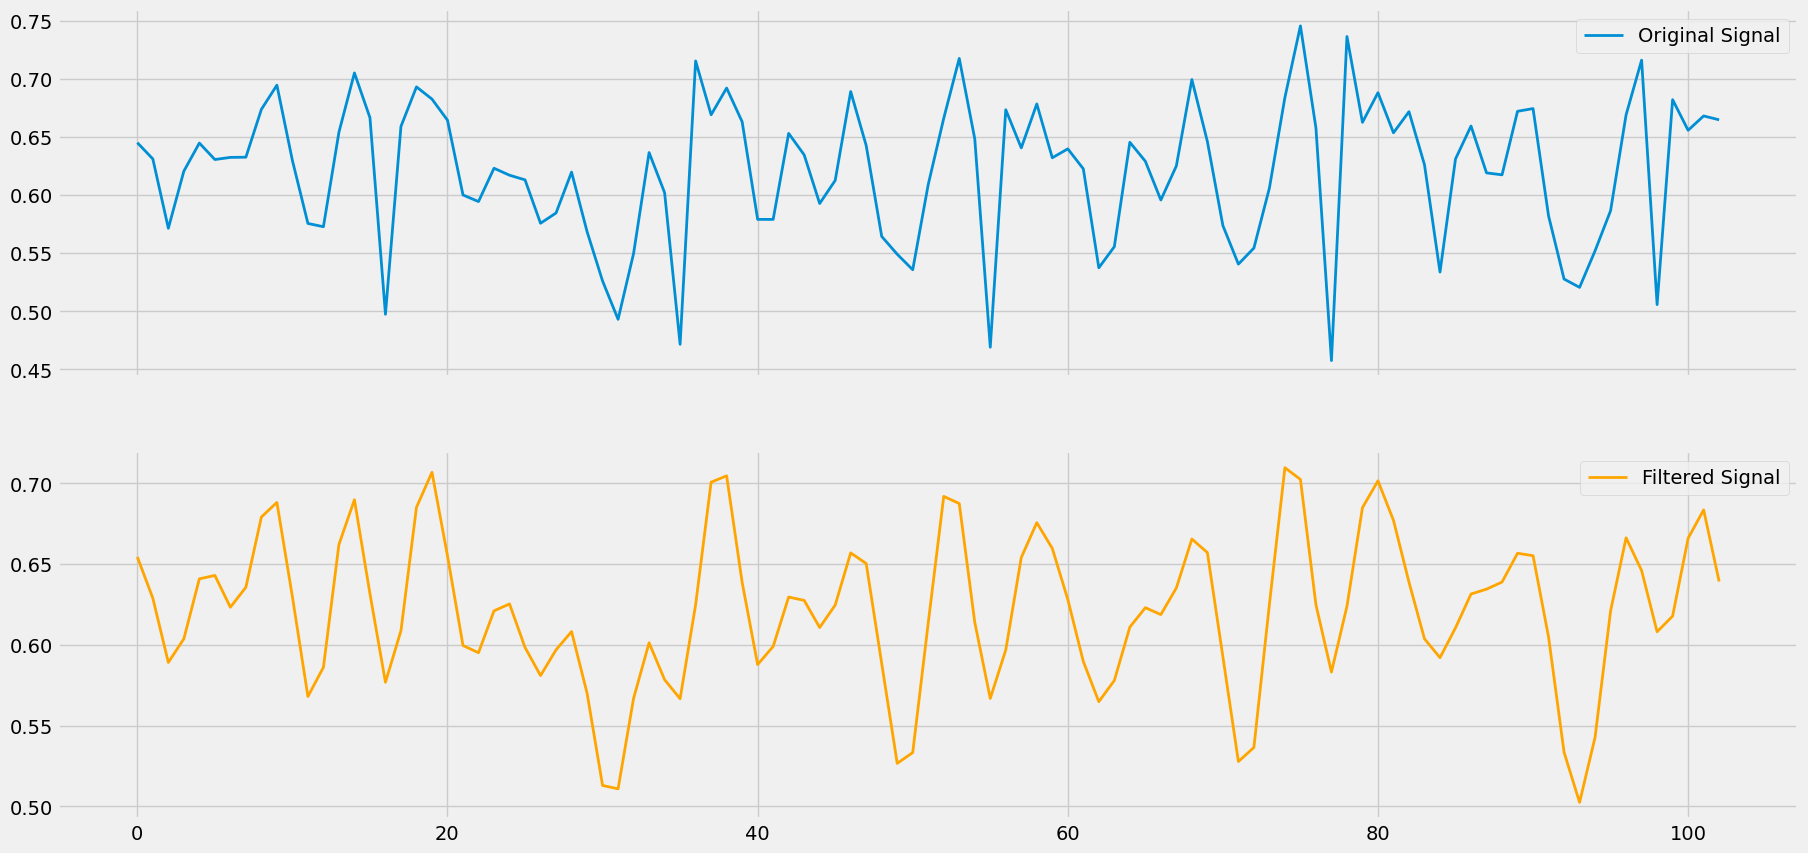

In [ ]:
df_filtered = df.copy()

lpf = LowPassFilter()

# Set filter parameters
sampling_frequency = 1000 / 200  # one second sempling frequency
cutoff_frequency = 1.2

# Apply low-pass filter to the "Accelerometer_y" column
df_filtered = lpf.low_pass_filter(df_filtered, "Accelerometer_y", sampling_frequency, cutoff_frequency)

# Filter the subset where "Set" equals 45
subset = df_filtered[df_filtered["Set"] == 45]

# Print the first label in the subset
print(subset["Label"].iloc[0])

# Plot the original and filtered signals
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))
ax[0].plot(subset["Accelerometer_y"].reset_index(drop=True), label="Original Signal")
ax[1].plot(subset["Accelerometer_y_lowpass"].reset_index(drop=True), label="Filtered Signal", color="orange")

# Add legends
ax[0].legend()
ax[1].legend()

plt.show()


In [13]:
# applying the filter to all the data
for col in columns:
    df_filtered = lpf.low_pass_filter(df_filtered, col, sampling_frequency, cutoff_frequency)
    df_filtered[col] = df_filtered[f"{col}_lowpass"]
    df_filtered.drop(columns=[f"{col}_lowpass"], inplace=True)

### **Principal Component Analysis (PCA)**

In [14]:
PCA = PrincipalComponentAnalysis()
df_pca = df_filtered.copy()

values = PCA.pca_variance(df_pca, columns)

#### ELBOW TECHNIQUE

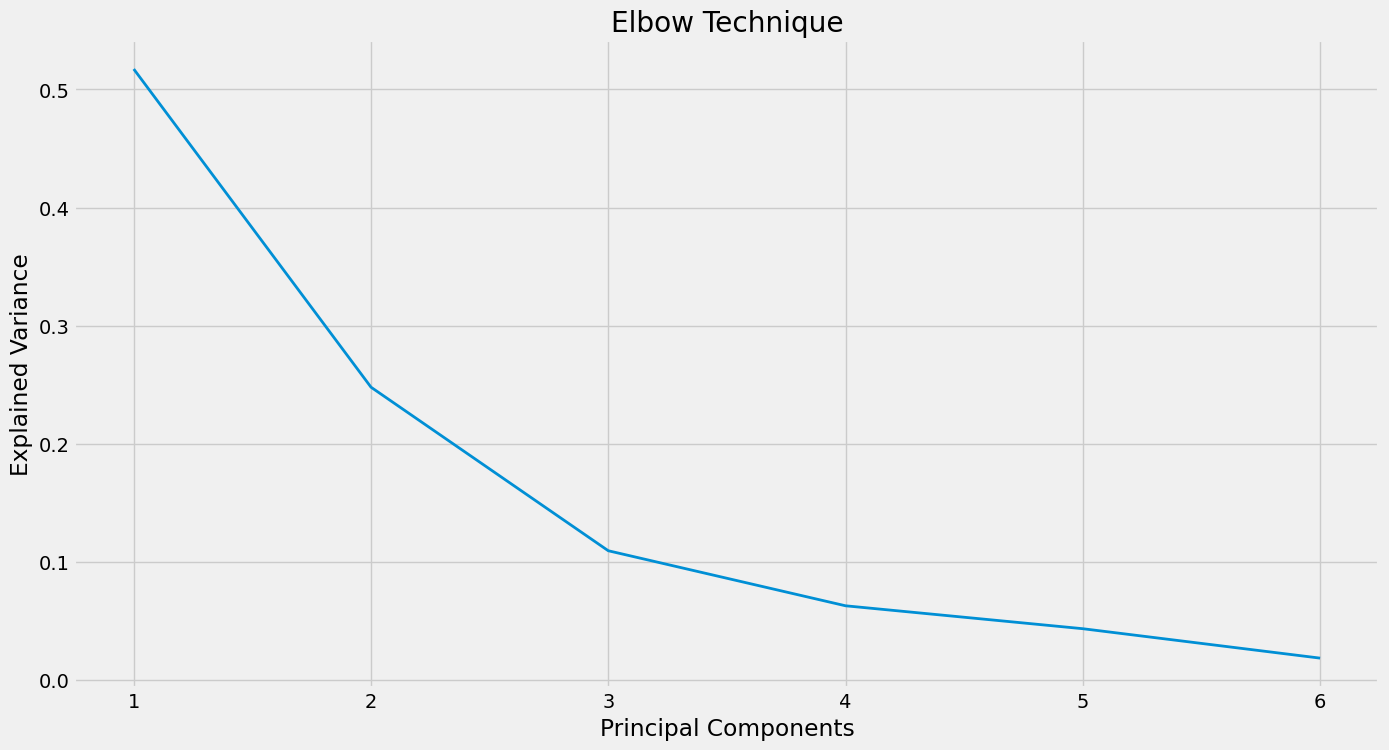

In [15]:
# Elbow technique
plt.figure(figsize=(15, 8))
plt.plot(range(1, len(columns) + 1), values)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Elbow Technique")
plt.show()

In [16]:
# Apply PCA
df_pca = PCA.apply_pca(df_pca, columns, 3)

#### **SQUERED**

In [17]:
df_squered = df_pca.copy()
Accelerometer_r = df_squered["Accelerometer_x"]**2 + df_squered["Accelerometer_y"]**2 + df_squered["Accelerometer_z"]**2
Gyroscope_r = df_squered["Gyroscope_x"]**2 + df_squered["Gyroscope_y"]**2 + df_squered["Gyroscope_z"]**2

df_squered["Accelerometer_r"] = np.sqrt(Accelerometer_r)
df_squered["Gyroscope_r"] = np.sqrt(Gyroscope_r)

#### **PCA and SQUARE PLOTS**

array([<Axes: >, <Axes: >], dtype=object)

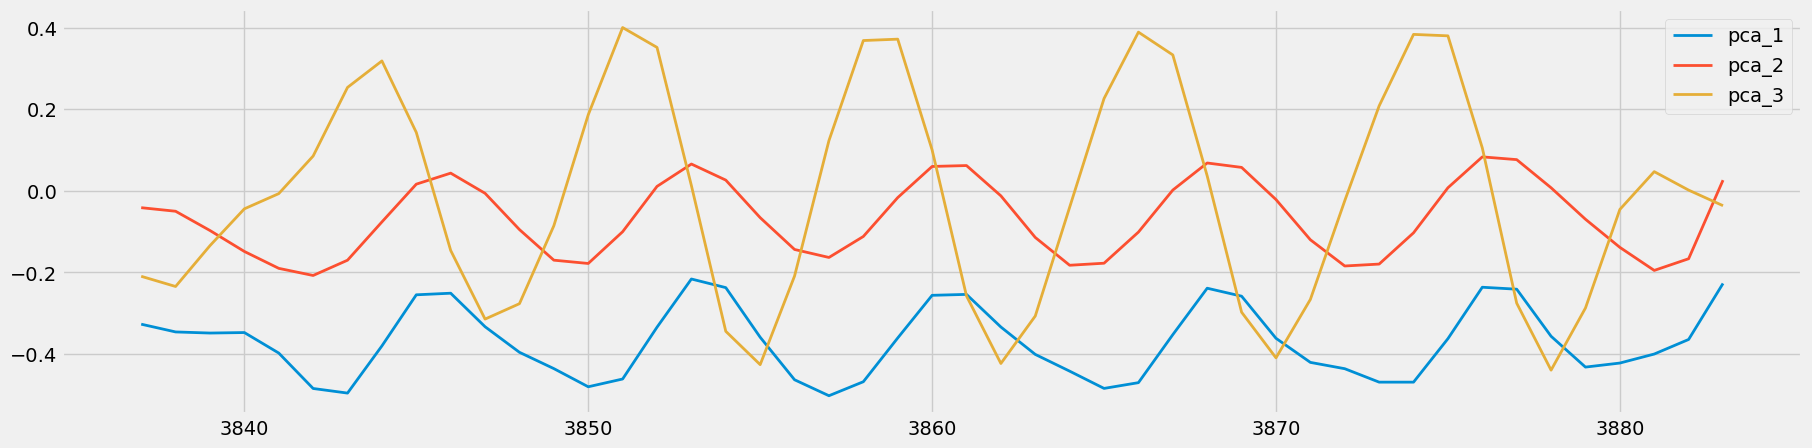

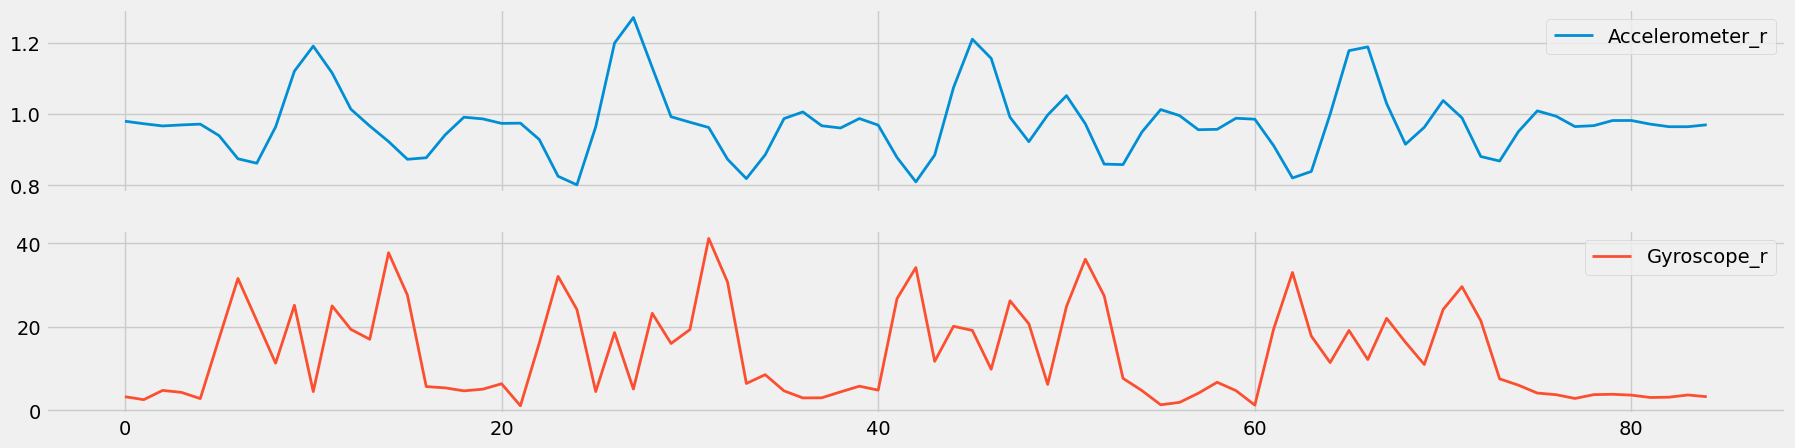

In [18]:
# in this case wee see that the data have noise
subset = df_pca[df_pca["Set"] == 35]
subset[["pca_1", "pca_2", "pca_3"]].plot()

subset = df_squered[df_squered["Set"] == 30]
subset[["Accelerometer_r", "Gyroscope_r"]].plot(subplots=True)

### Abstract Mean

In [19]:
df_squered.columns

Index(['epoch (ms)', 'Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z',
       'Gyroscope_x', 'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label',
       'Category', 'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r',
       'Gyroscope_r'],
      dtype='object')

In [20]:
mean = MeanTemporalAbstraction()
df_mean = df_squered.copy()

ws = int(1000/200)  # window size

df_mean_list = []
columns = columns+["Accelerometer_r", "Gyroscope_r"]
for set in df_mean["Set"].unique():
    subset = df_mean[df_mean["Set"] == set].copy()
    for col in columns:
        subset = mean.abstract_mean(subset, [col], ws)
    df_mean_list.append(subset)
df_mean = pd.concat(df_mean_list, ignore_index=True)


<Axes: >

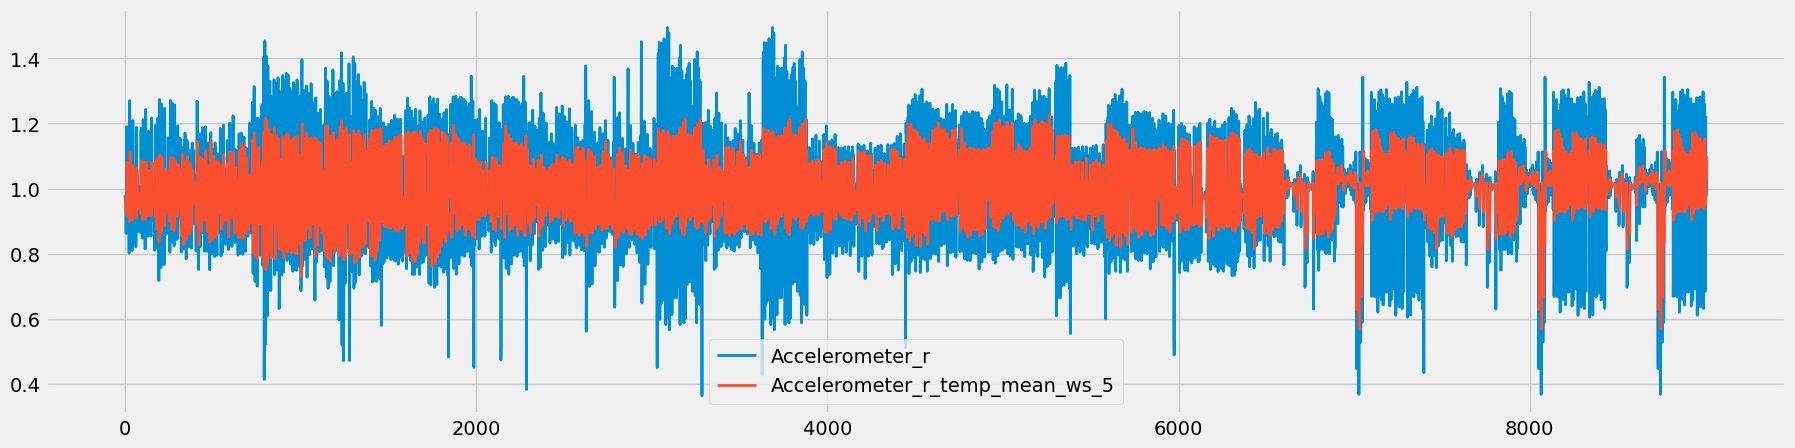

In [21]:
df_mean[["Accelerometer_r", "Accelerometer_r_temp_mean_ws_5"]].plot()

In [22]:
df_mean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9009 entries, 0 to 9008
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   epoch (ms)                      9009 non-null   object 
 1   Accelerometer_x                 9009 non-null   float64
 2   Accelerometer_y                 9009 non-null   float64
 3   Accelerometer_z                 9009 non-null   float64
 4   Gyroscope_x                     9009 non-null   float64
 5   Gyroscope_y                     9009 non-null   float64
 6   Gyroscope_z                     9009 non-null   float64
 7   Participants                    9009 non-null   object 
 8   Label                           9009 non-null   object 
 9   Category                        9009 non-null   object 
 10  Set                             9009 non-null   int64  
 11  pca_1                           9009 non-null   float64
 12  pca_2                           90

# Handeling the none values

In [23]:
df_mean.isnull().sum()

epoch (ms)                          0
Accelerometer_x                     0
Accelerometer_y                     0
Accelerometer_z                     0
Gyroscope_x                         0
Gyroscope_y                         0
Gyroscope_z                         0
Participants                        0
Label                               0
Category                            0
Set                                 0
pca_1                               0
pca_2                               0
pca_3                               0
Accelerometer_r                     0
Gyroscope_r                         0
Accelerometer_x_temp_mean_ws_5    364
Accelerometer_y_temp_mean_ws_5    364
Accelerometer_z_temp_mean_ws_5    364
Gyroscope_x_temp_mean_ws_5        364
Gyroscope_y_temp_mean_ws_5        364
Gyroscope_z_temp_mean_ws_5        364
Accelerometer_r_temp_mean_ws_5    364
Gyroscope_r_temp_mean_ws_5        364
dtype: int64

In [24]:
# List of columns to compute mean for
columns_with_nan = [
    'Accelerometer_x_temp_mean_ws_5',
    'Accelerometer_y_temp_mean_ws_5',
    'Accelerometer_z_temp_mean_ws_5',
    'Gyroscope_x_temp_mean_ws_5',
    'Gyroscope_y_temp_mean_ws_5',
    'Gyroscope_z_temp_mean_ws_5',
    'Accelerometer_r_temp_mean_ws_5',
    'Gyroscope_r_temp_mean_ws_5'
]

# Compute mean for each column, ignoring NaNs
means = df_mean[columns_with_nan].mean(skipna=True)

# Print or use the result
print("Means of columns (ignoring NaNs):")
print(means)

Means of columns (ignoring NaNs):
Accelerometer_x_temp_mean_ws_5     0.035311
Accelerometer_y_temp_mean_ws_5     0.067182
Accelerometer_z_temp_mean_ws_5     0.106472
Gyroscope_x_temp_mean_ws_5         1.178930
Gyroscope_y_temp_mean_ws_5        -2.153129
Gyroscope_z_temp_mean_ws_5         0.559606
Accelerometer_r_temp_mean_ws_5     0.997759
Gyroscope_r_temp_mean_ws_5        21.171596
dtype: float64


In [25]:
for col in columns_with_nan:
    df_mean[col] = df_mean[col].fillna(means[col])


In [26]:
# check the nan values in the data
df_mean.isnull().sum()

epoch (ms)                        0
Accelerometer_x                   0
Accelerometer_y                   0
Accelerometer_z                   0
Gyroscope_x                       0
Gyroscope_y                       0
Gyroscope_z                       0
Participants                      0
Label                             0
Category                          0
Set                               0
pca_1                             0
pca_2                             0
pca_3                             0
Accelerometer_r                   0
Gyroscope_r                       0
Accelerometer_x_temp_mean_ws_5    0
Accelerometer_y_temp_mean_ws_5    0
Accelerometer_z_temp_mean_ws_5    0
Gyroscope_x_temp_mean_ws_5        0
Gyroscope_y_temp_mean_ws_5        0
Gyroscope_z_temp_mean_ws_5        0
Accelerometer_r_temp_mean_ws_5    0
Gyroscope_r_temp_mean_ws_5        0
dtype: int64

#### **CLUSTERING**

##### - acceletrator_colums

In [27]:
df_cluster = df_mean.copy()
kvalues = range(1, 10)
inertia_acc = []

for k in kvalues:
    subset = df_cluster[columns_acc]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) 
    inertia_acc.append(kmeans.inertia_) 

# using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[columns_acc]
df_cluster["cluster_acc"] = kmeans.fit_predict(subset)


##### - gyroscope_colums

In [28]:
inertia_gyr = []
for k in kvalues:
    subset = df_cluster[columns_gyro]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset)
    inertia_gyr.append(kmeans.inertia_)

# using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[columns_gyro]
df_cluster["cluster_gyro"] = kmeans.fit_predict(subset)


#### **PLOTS**

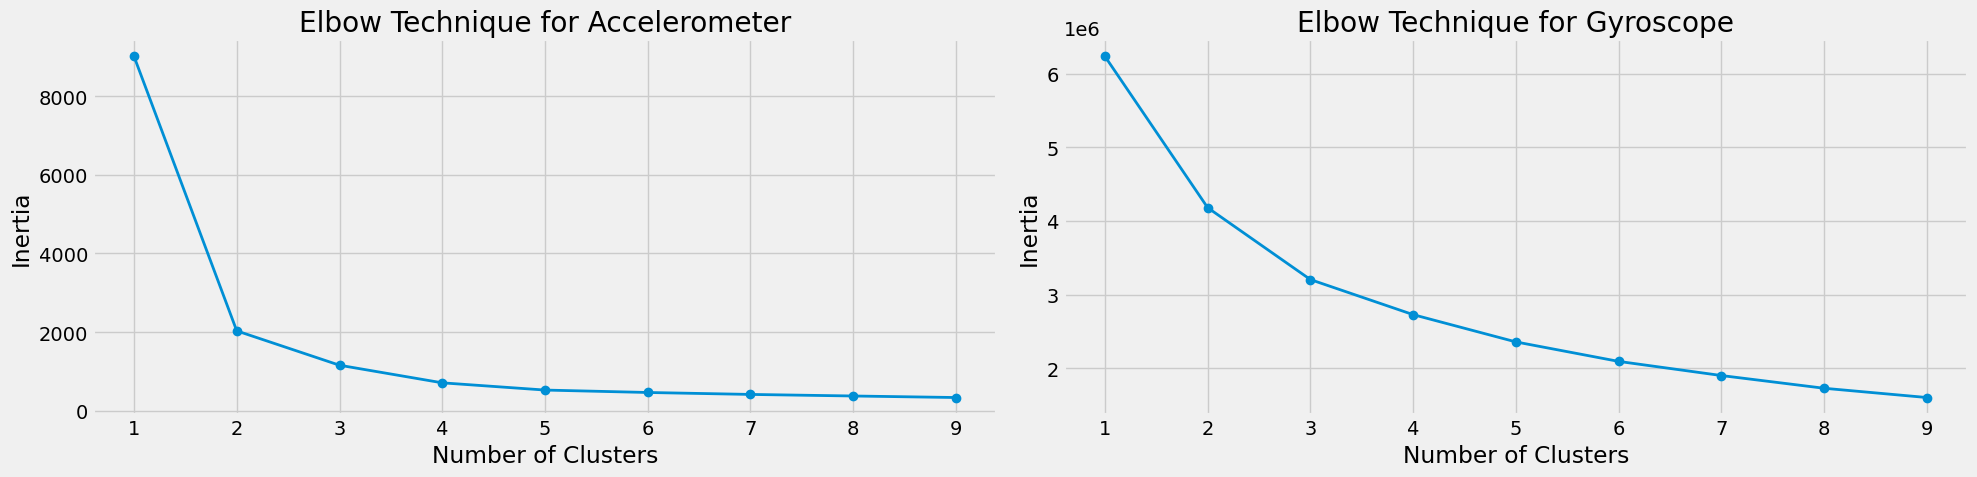

In [29]:
# Accelerometer
plt.subplot(1, 2, 1)
plt.plot(kvalues, inertia_acc, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Accelerometer")

# Gyroscope
plt.subplot(1, 2, 2)
plt.plot(kvalues, inertia_gyr, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Gyroscope")

plt.tight_layout()
plt.show()

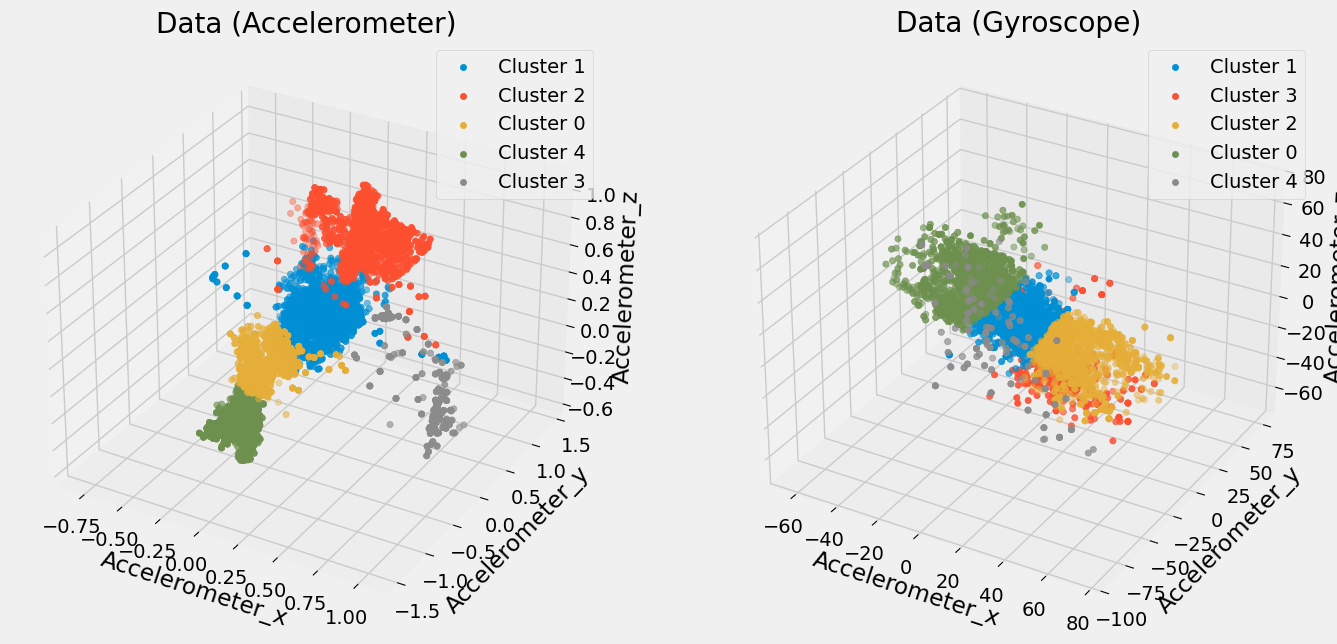

In [30]:
# plot the clusters for accelerometer
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(121, projection='3d')
for c in df_cluster["cluster_acc"].unique():
    subset = df_cluster[df_cluster["cluster_acc"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Data (Accelerometer)")
plt.legend()

# plot the clusters for gyroscope
ax = fig.add_subplot(122, projection='3d')
for c in df_cluster["cluster_gyro"].unique():
    subset = df_cluster[df_cluster["cluster_gyro"] == c]
    ax.scatter(subset["Gyroscope_x"], subset["Gyroscope_y"], subset["Gyroscope_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Data (Gyroscope)")
plt.legend()

plt.show()

In [31]:
# save the data
df_cluster.to_pickle('../processed_data/modelData.pkl')

### Fourier Transform for Feature Extraction

Fourier Transform changes a signal from the time domain to the frequency domain. This helps us spot patterns (like repeated movements) that are hard to see over time.

#### Why it's useful:
- **Find patterns**: Shows repeating behaviors or noise in the data.
- **Clean data**: Helps remove unwanted noise.
- **Better models**: Improves clustering and classification by giving a new view of the data.
